# GISDataVisualisation — Demonstration

**NASSA module 2026-Jarigsma-001** | Python implementation v1.1.0

Original module: *Visualising GIS Rasters and Vector Data in NetLogo* by Amber Esha Jarigsma (2026)  
Python implementation: João Messias Sousa da Silva (2026)

This notebook demonstrates how to use the `GISDataVisualisation` class to load and visualise
GIS raster and point-vector datasets. It replicates all import and display procedures from the
original NetLogo module:

| NetLogo procedure | Python equivalent |
|---|---|
| `load-coordinate-system` | inferred from raster CRS via `rasterio` |
| `import-continuous-raster` | `GISDataVisualisation.read_raster()` |
| `import-binary-raster` | `GISDataVisualisation.read_raster()` |
| `import-categorical-raster` | `GISDataVisualisation.read_raster()` |
| `import-points` | `GISDataVisualisation.read_points()` |
| `display-continuous-raster` + `display-points` | `GISDataVisualisation.show_continuous_with_points()` |
| `display-binary-raster` + `display-points` | `GISDataVisualisation.show_binary_with_points()` |
| `display-categorical-raster` | `GISDataVisualisation.show_categorical_raster()` |
| `display-data` | `GISDataVisualisation.display_all()` |

**Sample dataset:** SAGAscape (Boogers & Daems 2022, https://doi.org/10.5334/jcaa.90) —
southwest Anatolia, UTM zone 36N (EPSG:32636).

## Import dependencies

Standard libraries and the `GISDataVisualisation` module.
All dependencies are listed in `NASSA.yml` under `softwareDependencies`.

In [1]:
### Standard library path handling
from pathlib import Path

### Numerical array operations
import numpy as np

### Raster I/O — equivalent to the NetLogo GIS extension
import rasterio

### Vector data and coordinate reprojection
import geopandas as gpd

### Plotting
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

### Import the NASSA module
from GISDataVisualisation_v01 import GISDataVisualisation

## Set file paths

All data files are bundled in `python_implementation/` alongside this notebook.
Paths are resolved relative to the notebook's location so the code runs
on any machine without modification.

Replicates NetLogo procedure: `load-coordinate-system`
(the coordinate system is inferred automatically from each file's CRS metadata).

In [2]:
### Resolve the directory that contains this notebook
### Path('.').resolve() returns the working directory, which Jupyter sets to the
### notebook's folder when launched from that location
base_dir = Path(".").resolve()

### Paths to the four sample datasets
continuous_raster_path  = base_dir / "Altitude.asc"
binary_raster_path      = base_dir / "lakesAndRiversRasterized.asc"
categorical_raster_path = base_dir / "categorical_test.asc"
points_path             = base_dir / "Points" / "sagascape-sites-EPSG32636.shp"

### Confirm all files exist before loading
for label, p in [
    ("Continuous raster",  continuous_raster_path),
    ("Binary raster",      binary_raster_path),
    ("Categorical raster", categorical_raster_path),
    ("Points shapefile",   points_path),
]:
    status = "OK" if p.exists() else "NOT FOUND"
    print(f"{label}: {p.name} [{status}]")

Continuous raster: Altitude.asc [OK]
Binary raster: lakesAndRiversRasterized.asc [OK]
Categorical raster: categorical_test.asc [OK]
Points shapefile: sagascape-sites-EPSG32636.shp [OK]


## Initialise `GISDataVisualisation`

Creates an instance by passing file paths.
Data is **not** read from disk at this point — reading happens on demand when
a display method is called, mirroring the NetLogo workflow where import and
display are separate button actions.

Replicates NetLogo procedures: `import-continuous-raster`, `import-binary-raster`,
`import-categorical-raster`, `import-points`.

In [3]:
### Instantiate the visualiser with the sample dataset paths
vis = GISDataVisualisation(
    continuous_raster_path  = continuous_raster_path,
    binary_raster_path      = binary_raster_path,
    categorical_raster_path = categorical_raster_path,
    points_path             = points_path,
)

### Read the continuous raster once to inspect basic properties
data, extent, crs = vis.read_raster(vis.continuous_raster_path)

print(f"Grid size : {data.shape[0]} rows x {data.shape[1]} columns")
print(f"Value range: {np.nanmin(data):.1f} – {np.nanmax(data):.1f}")
print(f"Spatial extent (left, right, bottom, top): {[round(v, 1) for v in extent]}")
print(f"CRS: {crs}")

### Inspect the point layer
points = vis.read_points(crs)
print(f"\nPoint features: {len(points)} locations")
print(f"Point CRS: {points.crs}")

Grid size : 396 rows x 799 columns
Value range: 249.0 – 2621.0
Spatial extent (left, right, bottom, top): [230039.9, 309939.9, 4148060.1, 4187660.1]
CRS: None

Point features: 32 locations
Point CRS: EPSG:32636


## Visualise continuous raster with point features

Displays the elevation model as a green–yellow–orange colour gradient,
with SAGAscape site locations overlaid as scatter points.

The colour gradient replicates the RGB list hard-coded in the NetLogo
`display-continuous-raster` procedure.

Replicates NetLogo procedures: `display-continuous-raster`, `display-points`.

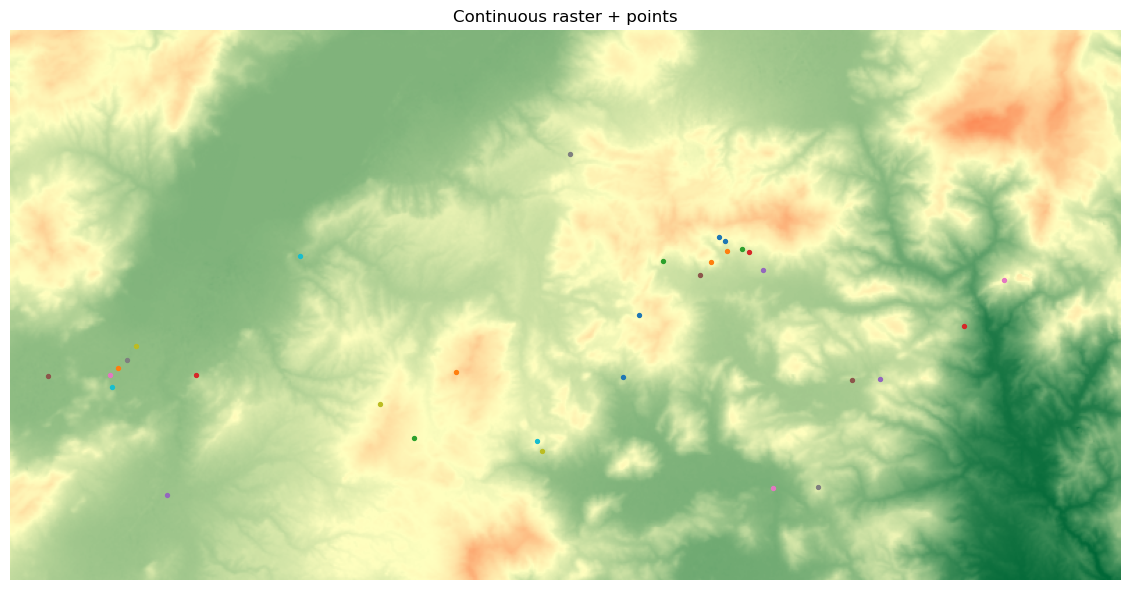

In [4]:
### show_continuous_with_points() replicates display-continuous-raster +
### display-points from the NetLogo interface
vis.show_continuous_with_points()

## Visualise binary raster with point features

Displays a lakes-and-rivers presence/absence mask using two discrete colours:
white (value 0, no water) and black (value 1, water present),
with site locations overlaid.

Replicates NetLogo procedures: `display-binary-raster`, `display-points`.

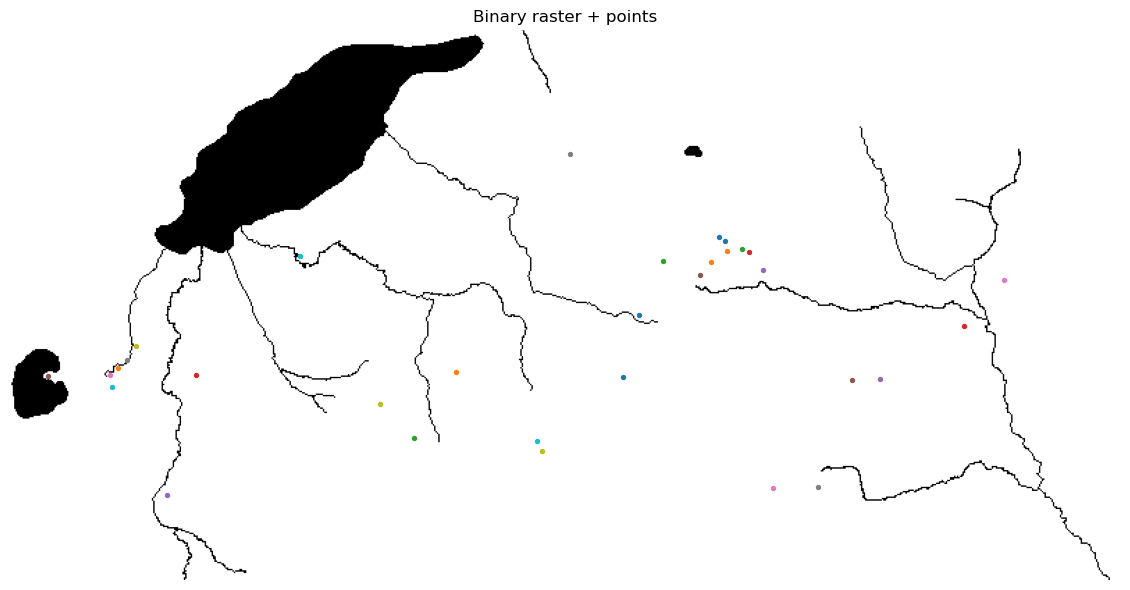

In [5]:
### show_binary_with_points() replicates display-binary-raster + display-points
vis.show_binary_with_points()

## Visualise categorical raster

Displays land-use or land-cover categories as discrete colours:
white (1), blue (2), red (3), green (4), yellow (5) — matching the NetLogo
`display-categorical-raster` colour assignments.

Replicates NetLogo procedure: `display-categorical-raster`.

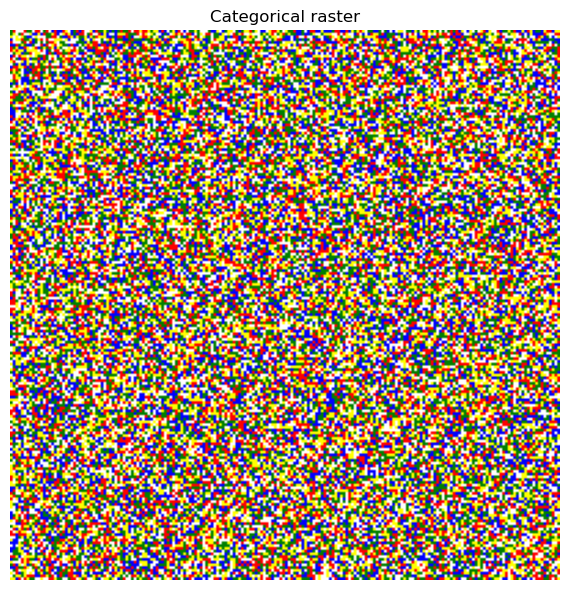

In [6]:
### show_categorical_raster() replicates display-categorical-raster
vis.show_categorical_raster()